### Loading Train and Test Data

In [1]:
import pandas as pd

feature_train = pd.read_csv('X_train_prepared.csv',  index_col=0)
target_train = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test = pd.read_csv('X_test_processed.csv',  index_col=0)
target_test = pd.read_csv('y_test.csv', index_col=0).squeeze()


### Creating the Model

In [3]:
from sklearn.linear_model import LinearRegression

# create and fit a linear regression
model = LinearRegression()

model.fit(feature_train, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Training and Calculating MAE, RMSE and R²

In [4]:
y_pred_train = model.predict(feature_train)
y_pred_test  = model.predict(feature_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(target_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(target_test, y_pred_test))
r2   = r2_score(target_test, y_pred_test)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  30.5630
RMSE: 41.0608
R²:   0.9798


We have good values for mae and rmse and the r2 score is high.

### Plotting for Analysation

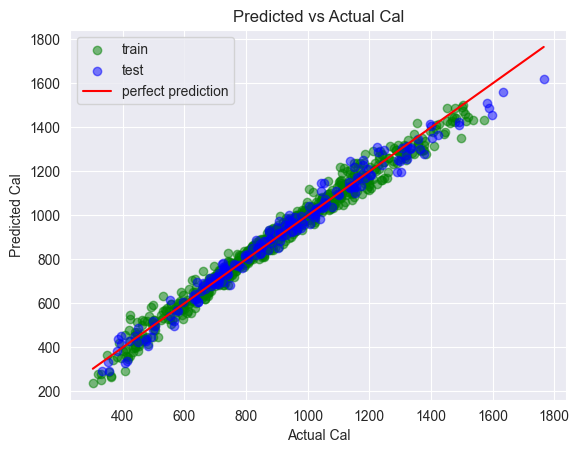

In [6]:
import matplotlib.pyplot as plt

plt.scatter(target_train, y_pred_train, c='green', label='train', alpha=0.5)
plt.scatter(target_test, y_pred_test, c='blue', label='test', alpha=0.5)

min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Cal')
plt.ylabel('Predicted Cal')
plt.legend()
plt.title('Predicted vs Actual Cal')
plt.show()

The figure is a confirmation for the mae, rmse and r2 values.

### Residual Distribution

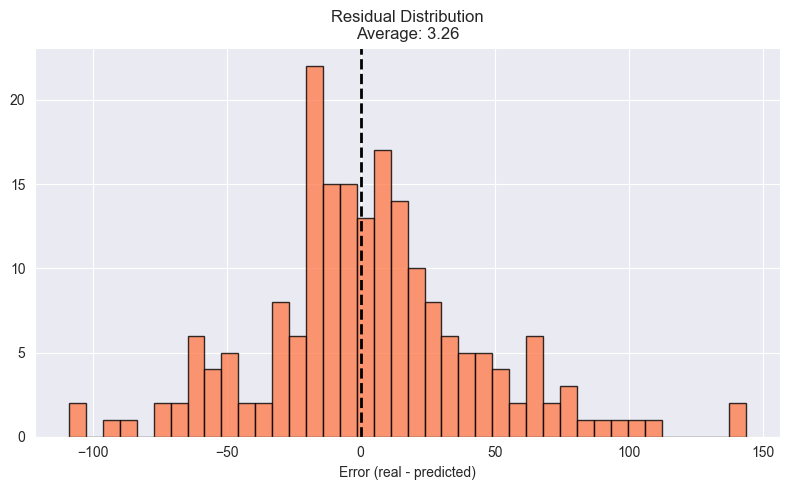

In [7]:
residuals = target_test.values - y_pred_test

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linestyle='--', lw=2)
plt.xlabel("Error (real - predicted)")
plt.title(f"Residual Distribution\nAverage: {residuals.mean():.2f}")
plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150)
plt.show()

The average is normal because it is not high in our context.

### Feature Importance 

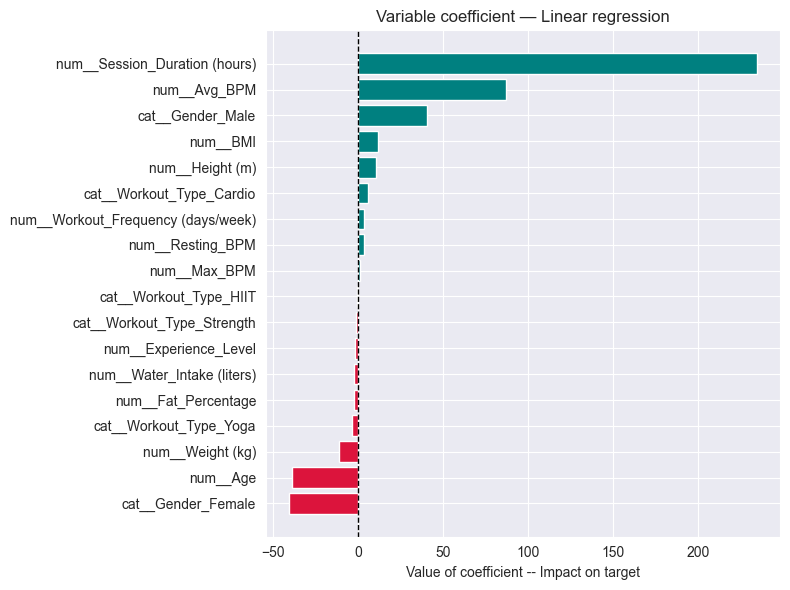

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.coef_

feat_df = pd.DataFrame({
    'Feature': feature_train.columns,
    'Importance': importance
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))

colors = ['crimson' if x < 0 else 'teal' for x in feat_df['Importance']]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)

plt.title("Variable coefficient — Linear regression")
plt.xlabel("Value of coefficient -- Impact on target")
plt.axvline(0, color='black', linestyle='--', lw=1) 
plt.tight_layout()
plt.savefig('feature_importance_linear.png', dpi=150)
plt.show()

Despite the fact that our coefficient is negative, the features are still important for the model. The negative values indicate an inverse relationship, based on the mathematical formula the algorithm uses.

### Learning Curve 

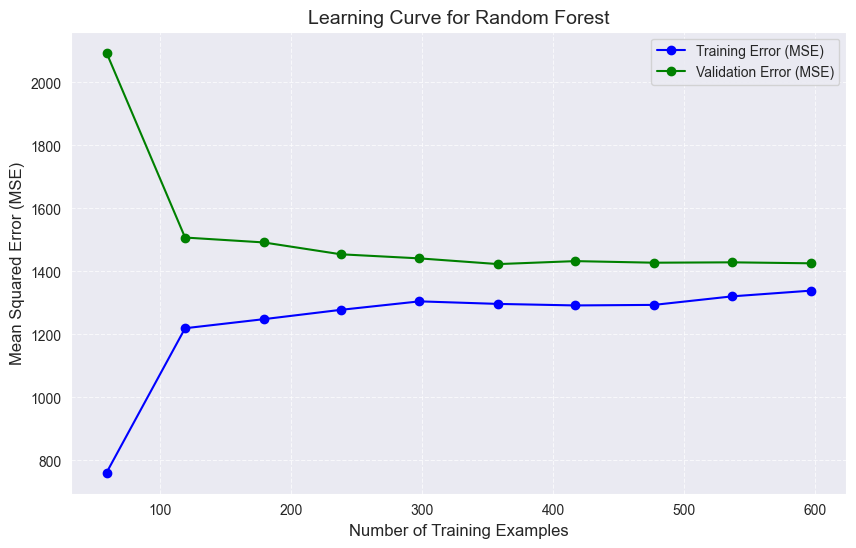

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate scores for the learning curve using rf_model
train_sizes, train_scores, test_scores = learning_curve(
    model, 
    feature_train, 
    target_train, 
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using MSE
    train_sizes=np.linspace(0.1, 1.0, 10), # From 10% to 100% of the training data
    n_jobs=-1 # Use all available CPU cores
)

# Convert negative scores to positive MSE
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Error (MSE)')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validation Error (MSE)')
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Learning Curve for Random Forest', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()